In [1]:
#Jonathan Borowsky
#Grabe lab
#07/11/24

#a script for computing the distances between charged groups of electrostatic locks of aac1 and ucp1 (and other slc25 proteins)
# to track C-M state transitions

In [1]:
import numpy as np
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#load inputs
# upperpath = "/Users/jonathanborowsky/Documents/grabelab/aac1-ucp1/aac1/trajectories/we18/"
#upperpath = "/home/jonathan/grabelab/aac1-ucp1/aac1/trajectories/westpa-18/"
# top_fn = "we18-input.gro"
# #top_fn = "input-files/input.gro"

# trj_fn = "whole-trj/we18-501-9-full-whole.xtc"
# #trj_fn = "trjs/501-009-trj-nr-pbcwhole-centerprot.xtc"

# trj = md.load(upperpath+trj_fn, top=upperpath+top_fn)

top_path = "/home/jonathan/Documents/grabelab/aac1-nt-transport/metadynamics/run4/inputs/gromacs_c/seg_06.gro"
trj_path = "/home/jonathan/Documents/grabelab/aac1-nt-transport/metadynamics/run4/run_c/1/mtd_seg_01_aligned.all.c.1.xtc"
trj = md.load(trj_path, top=top_path)

In [25]:
#calculate inter-atom distances over time
def get_atom_dists(resi1, name1, resi2, name2):
    
    atom1 = trj.top.select(f"resid {resi1-1} and name {name1}") 
    atom2 = trj.top.select(f"resid {resi2-1} and name {name2}") 
    
    print(trj.top.atom(atom1[0]).residue)
    print(trj.top.atom(atom2[0]).residue)

    dists = [np.linalg.norm(trj.xyz[f][atom2]-trj.xyz[f][atom1]) for f in range(trj.n_frames)]
    label = str(trj.top.atom(atom1[0]).residue)[0] + str(trj.top.atom(atom1[0]).residue)[1:].lower() + "-" + str(trj.top.atom(atom2[0]).residue)[0] + str(trj.top.atom(atom2[0]).residue)[1:].lower()
    
    return dists, label 
        

In [9]:
#test atoms
resi1 = 95
resi1_name = "NZ"
resi2 = 195
resi2_name = "CG"


In [10]:
# show spheres, resi 195+95+294+92+291+198 and not elem H and not name C+N+O
# util.cbay resi 195+95+294+92+291+198
# show spheres, resi 32+134+137+234+231+29 and not elem H and not name C+N+O
# util.cbay resi 32+134+137+234+231+29

In [14]:
#lock atoms (charge centers)
c_lock_positive_residues = [95, 198, 294]
c_lock_positive_atoms = ["NZ", "NZ", "NZ"]
c_lock_negative_residues = [195, 291, 92]
c_lock_negative_atoms = ["CG", "CG", "CG"]

m_lock_positive_residues = [32, 137, 234]
m_lock_positive_atoms = ["NZ", "CZ", "CZ"]
m_lock_negative_residues = [231, 29, 134]
m_lock_negative_atoms = ["CG", "CD", "CG"]

In [12]:
print("+".join([str(i) for i in c_lock_positive_residues+c_lock_negative_residues+m_lock_positive_residues+m_lock_negative_residues]))

95+195+294+198+291+92+32+137+234+231+29+134


LYS95
ASP195
LYS32
ASP231
LYS198
ASP291
ARG137
GLU29
LYS294
ASP92
ARG234
ASP134


Text(0, 0.5, 'distance (nm)')

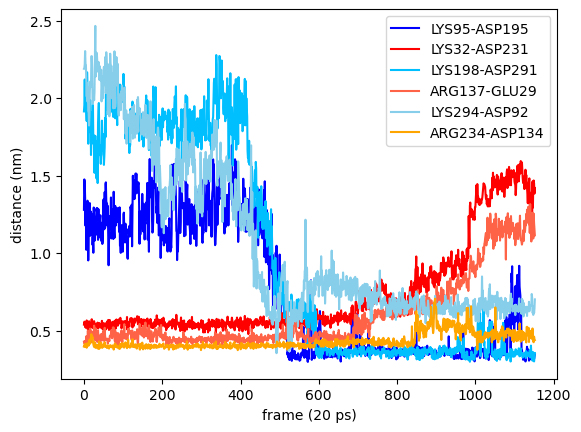

In [15]:
#calculate the distances between each pair of residues

c_colors = ["blue", "deepskyblue", "skyblue"]
m_colors = ["red", "tomato", "orange"]

c_lock_dists = []
m_lock_dists = []

for i in range(3):
    
    cldi, clabel = get_atom_dists(c_lock_positive_residues[i], c_lock_positive_atoms[i], c_lock_negative_residues[i], c_lock_negative_atoms[i])
    mldi, mlabel = get_atom_dists(m_lock_positive_residues[i], m_lock_positive_atoms[i], m_lock_negative_residues[i], m_lock_negative_atoms[i])

    plt.plot(cldi, color = c_colors[i], label = clabel)
    plt.plot(mldi, color = m_colors[i], label = mlabel)
    
    c_lock_dists.append(cldi)
    m_lock_dists.append(mldi)

plt.legend()
plt.xlabel("frame (20 ps)")
plt.ylabel("distance (nm)")

LYS95
ASP195
LYS198
ASP291
LYS294
ASP92
LYS32
ASP231
ARG137
GLU29
ARG234
ASP134


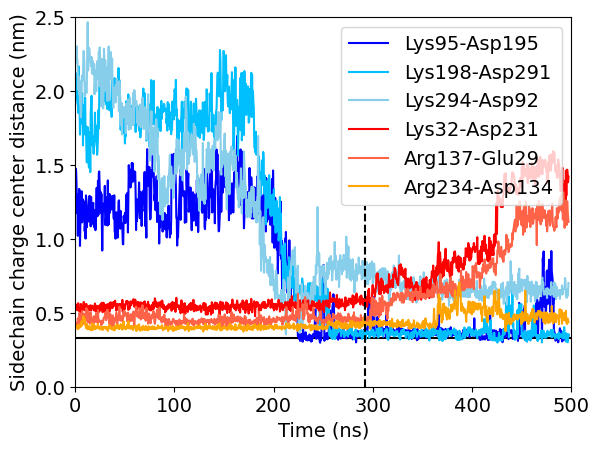

In [26]:
#FIGURE FOR 2026 BPS POSTER

plt.rcParams['font.size'] = 14

plt.axhline(0.33, color="black", zorder=0)

c_colors = ["blue", "deepskyblue", "skyblue"]
m_colors = ["red", "tomato", "orange"]

c_lock_dists = []
m_lock_dists = []

for i in range(3):
    
    cldi, clabel = get_atom_dists(c_lock_positive_residues[i], c_lock_positive_atoms[i], c_lock_negative_residues[i], c_lock_negative_atoms[i])

    times = np.arange(len(cldi)) * 497.6/len(cldi)

    plt.plot(times, cldi, color = c_colors[i], label = clabel)
    
    c_lock_dists.append(cldi)

for i in range(3):
    
    mldi, mlabel = get_atom_dists(m_lock_positive_residues[i], m_lock_positive_atoms[i], m_lock_negative_residues[i], m_lock_negative_atoms[i])

    times = np.arange(len(mldi)) * 497.6/len(mldi)

    plt.plot(times, mldi, color = m_colors[i], label = mlabel)
    
    m_lock_dists.append(mldi)

#h-bond threshold; not for salt bridges
#plt.axhline(0.33, color="black", alpha = 0.15, zorder=99)

#frame used as occluded state representative
t_occ_rep = 676 * 497.6/len(c_lock_dists[0])
plt.plot([t_occ_rep, t_occ_rep], [0, 1.22], color="black", linestyle="--", zorder=10)

#plt.axvline(676 * 497.6/len(c_lock_dists[0]), color="black", linestyle="--", zorder=10)

plt.ylim(0, 2.5)
plt.xlim(0, 500)

plt.xlabel("Time (ns)")
plt.ylabel("Sidechain charge center distance (nm)")

plt.legend()
#plt.legend(["0.33 nm hydrogen bond cutoff", "ATP to C side bulk water", "ATP to M side bulk water"], fontsize=11)

plt.savefig("aac1-atp-locks.png", dpi=600, bbox_inches="tight")

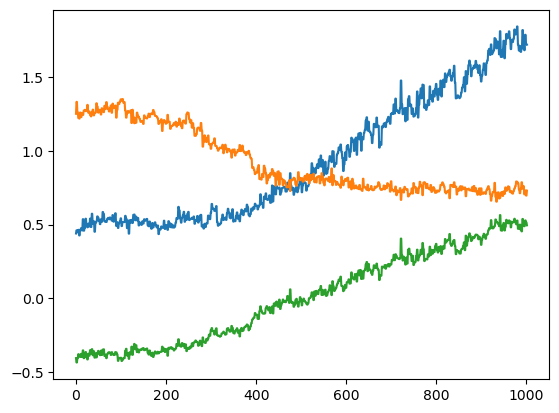

In [10]:
plt.plot(np.mean(c_lock_dists, axis = 0))
plt.plot(np.mean(m_lock_dists, axis = 0))
plt.plot(np.mean(c_lock_dists+[[-i for i in j] for j in m_lock_dists], axis = 0))
#note that the third line, being an average, is a factor of 2 smaller than the difference

In [11]:
len(c_lock_dists+[[-i for i in j] for j in m_lock_dists])

6